In [1]:
import sys
sys.path.append('C:/Users/Lenovo/Desktop/2024_E/tools/')
from CM_dataset import CM_dataset
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator

In [2]:
CM_data = CM_dataset(1000)

In [3]:
batch_size = 16
data_loader = LoadArray(CM_data,batch_size)

In [4]:
model = gluon.nn.Sequential()
model.add(

    # gluon.nn.Dense(64, activation='relu'),
    gluon.nn.Dense(5),
    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))

In [5]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'adam',{'learning_rate':0.001})

In [6]:
best_loss = float(100000)

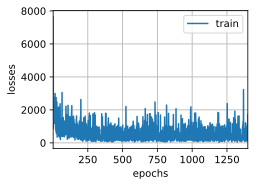

In [7]:
epochs = 1400
animator = Animator(xlabel='epochs',ylabel='losses',legend=['train'],xlim=[1,epochs])
for epoch in range(epochs):
    epoch_loss = 0
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
                # print(feature,model(feature))
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
            epoch_loss += temp
    animator.add(epoch+1, (temp,))
    
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        model.save_parameters(r'C:/Users/Lenovo/Desktop/2024_E/model_params/model_params.params')
                

In [8]:
model[0].weight.data()

array([[-0.9434919 ,  1.2987214 ,  0.00513097],
       [-0.96682006,  1.2794796 ,  0.02155426],
       [ 0.97556597, -1.2990535 , -0.02372661],
       [ 0.96563584, -1.3008565 , -0.00826634],
       [ 0.91918   , -1.3284322 , -0.00254154]])

In [16]:
from mxnet import np, npx
npx.set_np()
feature = np.array([[114.47,	57.29,	368



]])
model(feature)

array([[170.2459]])